In [499]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json 
from matplotlib_venn import venn2
import itertools
import mpltern

import warnings

# Suppress warnings
warnings.simplefilter(action='ignore', category=Warning)

fsize = 15
plt.rcParams.update({"font.size": fsize})
%config InlineBackend.figure_format = 'retina'

In [ ]:
def load_evidence(fn):
    # we only want derived since we're going to compare gene ids
    df = pd.read_json(fn)
    ddf = df['derived'].apply(pd.Series)

    # normalize the string values for cell types
    ddf["cell_type_label"] = ddf["cell_type_label"].str.strip().str.upper()
    ddf["cell_type_id"] = ddf["cell_type_id"].str.strip().str.upper()
    
    # normalize the string values for genes
    ddf["feature_name"] = ddf["feature_name"].str.strip().str.upper()
    ddf["feature_identifier"] = ddf["feature_identifier"].str.strip().str.upper()
    hddf = ddf.query("organism == 'homo_sapiens'")
    return hddf

def set_itx(a, b, vals=False):
    itx = np.intersect1d(a, b)
    if vals:
        return itx
    return itx.shape[0]

def set_diff(a, b, vals=False):
    diff = np.setdiff1d(a, b)
    if vals:
        return diff
    return diff.shape[0]

def set_cmp(a,b, vals=False):
    return (set_diff(a,b,vals), set_itx(a,b,vals), set_diff(b,a,vals))

def get_ctmap(ctmap_fn):
    with open(ctmap_fn, 'r') as file:
        map_dict = json.load(file)
        upper_map = {k.upper(): [v.upper() for v in vals] for k, vals in map_dict.items()}
        rev_map = {v: k for k, vals in upper_map.items() for v in vals}
    return (upper_map, rev_map)

In [666]:
ds = "adipose_Hildreth2021"
# ds = "adipose_Vijay2019"
# ds = "adipose_Emont2022"

fn_hmn   = f"../../data/{ds}/evidence_human/evidence.json"
fn_deg   = f"../../data/{ds}/evidence_deg/evidence_unfiltered.json"
ctmap_fn = f"../../data/{ds}/ctmap.json"

ctmap, rev_ctmap = get_ctmap(ctmap_fn)

hmn = load_evidence(fn_hmn)
deg = load_evidence(fn_deg)

hmn["cell_type_id"] = hmn["cell_type_label"].map(lambda x: rev_ctmap[x])
deg["cell_type_id"] = deg["cell_type_label"].map(lambda x: rev_ctmap[x])

## Global Gene and Celltype comparisons

In [667]:
# feature = "feature_identifier" # <-- to use once we fill in the id from the gene name
feature = "feature_name"

hmn_features = pd.Series(hmn[feature].unique()).dropna().tolist()
deg_features = pd.Series(deg[feature].unique()).dropna().tolist()

l, x, r  = set_cmp(hmn_features, deg_features)                # raw counts
nl, nx, nr = np.array([l,x,r]) / np.array([l,x,r]).sum()      # normalized counts
lv, xv, rv  = set_cmp(hmn_features, deg_features, vals=True)  # actual lists

gene_vals = [l,x,r]
gene_nvals = [nl,nx,nr]

print(f"Human v DEG ({feature})")
print("\tleft\titx\tright")
print(f"raw\t{l}\t{x}\t{r}")
print(f"norm\t{nl:.2f}\t{nx:.2f}\t{nr:.2f}")

Human v DEG (feature_name)
	left	itx	right
raw	37	53	7590
norm	0.00	0.01	0.99


In [668]:
# feature = "cell_type_label" # eventually change this to comparing based on a map we can create
feature = "cell_type_id"

hmn_features = pd.Series(hmn[feature].unique()).dropna().tolist()
deg_features = pd.Series(deg[feature].unique()).dropna().tolist()

l, x, r  = set_cmp(hmn_features, deg_features)               # raw counts
nl, nx, nr = np.array([l,x,r]) / np.array([l,x,r]).sum()     # normalized counts
lv, xv, rv  = set_cmp(hmn_features, deg_features, vals=True) # actual lists

ct_vals = [l,x,r]
ct_nvals = [nl,nx,nr]

print(f"Human v DEG ({feature})")
print("\tleft\titx\tright")
print(f"raw\t{l}\t{x}\t{r}")
print(f"norm\t{nl:.2f}\t{nx:.2f}\t{nr:.2f}")

Human v DEG (cell_type_id)
	left	itx	right
raw	2	9	6
norm	0.12	0.53	0.35


In [669]:
# Define the multi-level column structure and data
columns = pd.MultiIndex.from_product(
    [["cell_type_id", "feature_name"], ["left", "itx", "right"]],
    names=["Feature", "Set Comparison"]
)

data = [
    ct_vals +  gene_vals,  # raw values
   ct_nvals + gene_nvals  # normalized values
]

# Create the DataFrame
df = pd.DataFrame(data, columns=columns, index=["raw", "norm"])



In [670]:
df

Feature        cell_type_id                     feature_name             \
Set Comparison         left       itx     right         left        itx   
raw                2.000000  9.000000  6.000000    37.000000  53.000000   
norm               0.117647  0.529412  0.352941     0.004818   0.006901   

Feature                      
Set Comparison        right  
raw             7590.000000  
norm               0.988281

## Cell-type-specific comparisons

In [ ]:
def ctg_metric(df1, df2, gene_col = "feature_name", ct_col = "cell_type_label", df1_label="hmn", df2_label="deg", comm_ct=True, comm_gene=True):
    # common cell types
    common_ct = np.intersect1d(df1[ct_col].unique(), df2[ct_col].unique())
    common_gn = np.intersect1d(df1[gene_col].unique(), df2[gene_col].unique())


    # comm_df1 = df1[df1[ct_col].isin(common_ct)]
    # comm_df2 = df2[df2[ct_col].isin(common_ct)]
    
    # here we filter for the same set of cell types and genes <-- note we may want to change this!
    if comm_ct and not comm_gene:
        comm_df1 = df1[df1[ct_col].isin(common_ct)]
        comm_df2 = df2[df2[ct_col].isin(common_ct)]
    elif comm_gene and not comm_ct:
        comm_df1 = df1[df1[gene_col].isin(common_gn)]
        comm_df2 = df2[df2[gene_col].isin(common_gn)]
    elif comm_ct and comm_gene:
        comm_df1 = df1[df1[ct_col].isin(common_ct) & df1[gene_col].isin(common_gn)]
        comm_df2 = df2[df2[ct_col].isin(common_ct) & df2[gene_col].isin(common_gn)]
    else:
        comm_df1 = df1
        comm_df2 = df2

    df1_ctg_list = comm_df1.groupby(ct_col)[gene_col].apply(lambda x: x.unique())
    if comm_ct:
        df1_ctg_list = df1_ctg_list.reindex(common_ct, fill_value=[])
    df2_ctg_list = comm_df2.groupby(ct_col)[gene_col].apply(lambda x: x.unique())
    if comm_ct:
        df2_ctg_list = df2_ctg_list.reindex(common_ct, fill_value=[])

    # now take the left set diff, intersection, and right set diff for every pair of cell types in the two dataframes
    ctg_cmp = {}
    ctg_cmp_vals = {}
    for ct1 in df1_ctg_list.index:
        for ct2 in df2_ctg_list.index:
            l, x, r  = set_cmp(df1_ctg_list[ct1], df2_ctg_list[ct2])
            lv, xv, rv  = set_cmp(df1_ctg_list[ct1], df2_ctg_list[ct2], vals=True)
            ctg_cmp[(ct1, ct2)] = (l, x, r)
            ctg_cmp_vals[(ct1, ct1)] = (lv, xv, rv)

    pvt = pd.DataFrame(ctg_cmp.values(), index=ctg_cmp.keys(), columns=["l", "x", "r"]).reset_index(names=[df1_label, df2_label]).pivot(index=df1_label, columns=df2_label, values=["l", "x", "r"]).fillna(0)

    df1_ct = pvt.index
    df2_ct = pvt.columns.levels[1]
    mtx = pvt.to_numpy().reshape(len(df1_ct), 3, len(df2_ct))
    norm_mtx = mtx / mtx.sum(axis=1)[:, np.newaxis, :]
    mtx = mtx.transpose(0,2,1)
    norm_mtx = norm_mtx.transpose(0,2,1)
    return (mtx, norm_mtx, df1_ct, df2_ct)

## All "OG" cell type names between human and DEG

In [671]:
(mtx, norm_mtx, hmnct, degct) = ctg_metric(hmn, deg, gene_col = "feature_name", ct_col = "cell_type_label", df1_label="hmn", df2_label="deg", comm_ct=False, comm_gene=True)

In [672]:
df = pd.DataFrame(mtx.tolist(), index=hmnct, columns=degct)
df.head()

deg,ADIPOCYTE,ASPC,B_CELL,DENDRITIC_CELL,ENDOMETRIUM,ENDOTHELIAL,LEC,MACROPHAGE,MAST_CELL,MESOTHELIUM,MONOCYTE,NEUTROPHIL,NK_CELL,PERICYTE,SMC,T_CELL
hmn,,,,,,,,,,,,,,,,
APCS (ADIPOCYTE PRECURSOR CELLS),"[2, 0, 5]","[0, 2, 2]","[2, 0, 5]","[2, 0, 18]","[2, 0, 3]","[2, 0, 5]","[2, 0, 6]","[2, 0, 16]","[1, 1, 6]","[2, 0, 1]","[2, 0, 13]","[2, 0, 6]","[2, 0, 13]","[2, 0, 3]","[2, 0, 4]","[2, 0, 10]"
CONVENTIONAL TYPE 1 DENDRITIC CELLS (CDC1S),"[3, 1, 4]","[4, 0, 4]","[2, 2, 3]","[1, 3, 15]","[4, 0, 3]","[3, 1, 4]","[3, 1, 5]","[2, 2, 14]","[3, 1, 6]","[3, 1, 0]","[2, 2, 11]","[3, 1, 5]","[4, 0, 13]","[3, 1, 2]","[4, 0, 4]","[3, 1, 9]"
CONVENTIONAL TYPE 2 DENDRITIC CELLS SUBSET A (CDC2AS),"[7, 0, 5]","[7, 0, 4]","[5, 2, 3]","[3, 4, 14]","[7, 0, 3]","[6, 1, 4]","[7, 0, 6]","[5, 2, 14]","[7, 0, 7]","[7, 0, 1]","[5, 2, 11]","[6, 1, 5]","[6, 1, 12]","[7, 0, 3]","[7, 0, 4]","[5, 2, 8]"
CONVENTIONAL TYPE 2 DENDRITIC CELLS SUBSET B (CDC2BS),"[6, 0, 5]","[6, 0, 4]","[5, 1, 4]","[1, 5, 13]","[6, 0, 3]","[6, 0, 5]","[5, 1, 5]","[4, 2, 14]","[6, 0, 7]","[6, 0, 1]","[4, 2, 11]","[5, 1, 5]","[6, 0, 13]","[6, 0, 3]","[6, 0, 4]","[6, 0, 10]"
ENDOS (ENDOTHELIAL CELLS),"[2, 0, 5]","[1, 1, 3]","[2, 0, 5]","[2, 0, 18]","[2, 0, 3]","[1, 1, 4]","[2, 0, 6]","[2, 0, 16]","[2, 0, 7]","[2, 0, 1]","[2, 0, 13]","[2, 0, 6]","[2, 0, 13]","[2, 0, 3]","[2, 0, 4]","[2, 0, 10]"


In [673]:
(mtx, norm_mtx, hmnct, degct) = ctg_metric(hmn, deg, gene_col = "feature_name", ct_col = "cell_type_id", df1_label="hmn", df2_label="deg", comm_ct=True, comm_gene=True)

In [674]:
df = pd.DataFrame(mtx.tolist(), index=hmnct, columns=degct)
df.head()

deg,ADIPOCYTE PRECURSOR CELL,DENDRITIC CELL,ENDOTHELIAL CELLS,MACROPHAGE,MONOCYTE,NATURAL KILLER CELL,NEUTROPHIL,SMOOTH MUSCLE CELLS,T CELL
hmn,,,,,,,,,
ADIPOCYTE PRECURSOR CELL,"[0, 3, 1]","[3, 0, 18]","[3, 0, 10]","[3, 0, 16]","[3, 0, 13]","[3, 0, 13]","[3, 0, 6]","[3, 0, 4]","[3, 0, 10]"
DENDRITIC CELL,"[16, 0, 4]","[5, 11, 7]","[12, 4, 6]","[9, 7, 9]","[9, 7, 6]","[15, 1, 12]","[13, 3, 3]","[16, 0, 4]","[13, 3, 7]"
ENDOTHELIAL CELLS,"[1, 1, 3]","[2, 0, 18]","[1, 1, 9]","[2, 0, 16]","[2, 0, 13]","[2, 0, 13]","[2, 0, 6]","[2, 0, 4]","[2, 0, 10]"
MACROPHAGE,"[11, 1, 3]","[9, 3, 15]","[9, 3, 7]","[6, 6, 10]","[10, 2, 11]","[12, 0, 13]","[12, 0, 6]","[10, 2, 2]","[12, 0, 10]"
MONOCYTE,"[7, 0, 4]","[4, 3, 15]","[6, 1, 9]","[4, 3, 13]","[4, 3, 10]","[5, 2, 11]","[4, 3, 3]","[6, 1, 3]","[6, 1, 9]"


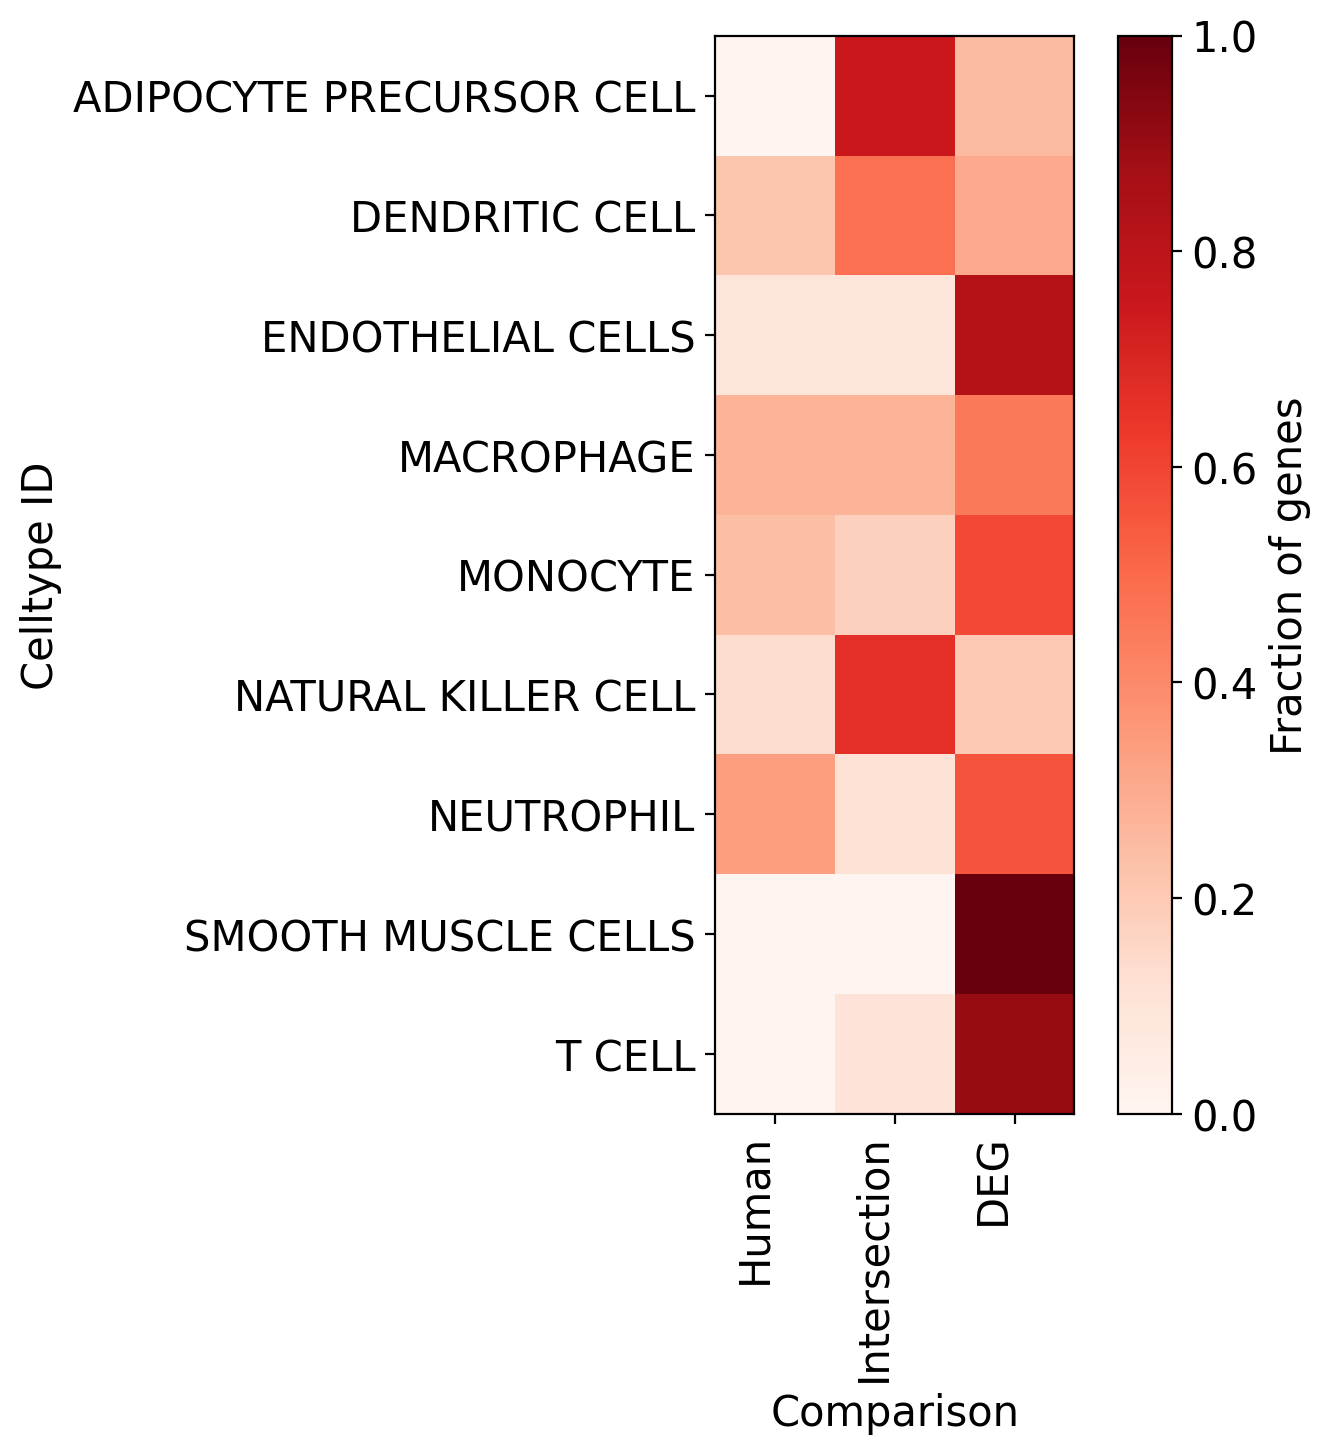

In [675]:
fig, ax = plt.subplots(figsize=(7, 7))

xlabels = ["Human", "Intersection", "DEG"]
eye = norm_mtx[np.eye(norm_mtx.shape[0], dtype=bool)]

cax = ax.imshow(eye, cmap="Reds")

ax.set(**{
    "xticks": np.arange(len(xlabels)),
    "yticks": np.arange(len(hmnct)),
    "xticklabels": xlabels,
    "yticklabels": hmnct,
    "xlabel": "Comparison",
    "ylabel": "Celltype ID"
})
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')
plt.colorbar(cax, fraction=0.052, pad=0.04, label="Fraction of genes")
plt.show()


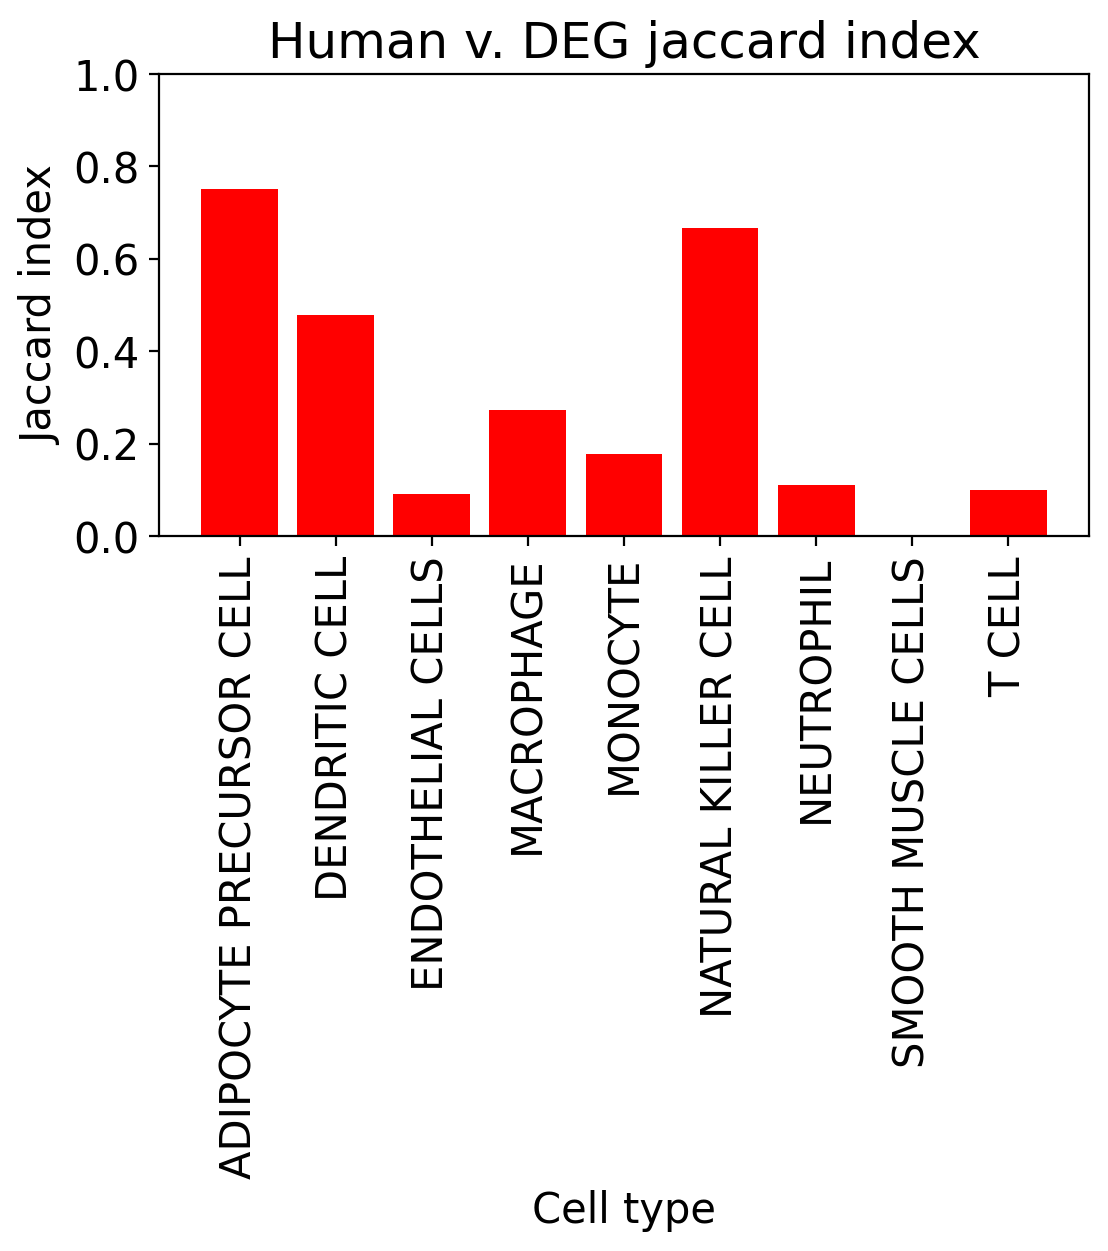

In [676]:
fig, ax = plt.subplots(figsize=(6, 3))

eye = norm_mtx[np.eye(norm_mtx.shape[0], dtype=bool)]
jac = eye[:,1] / (eye[:,0] + eye[:,2] + eye[:,1])

ax.bar(np.arange(len(hmnct)), jac, color="red")
ax.set(**{
    "xticks": np.arange(len(hmnct)),
    "xticklabels": hmnct,
    "xlabel": "Cell type",
    "ylabel": "Jaccard index",
    "title": "Human v. DEG jaccard index",
    "ylim": (0,1)
})
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, horizontalalignment='center')
plt.show()


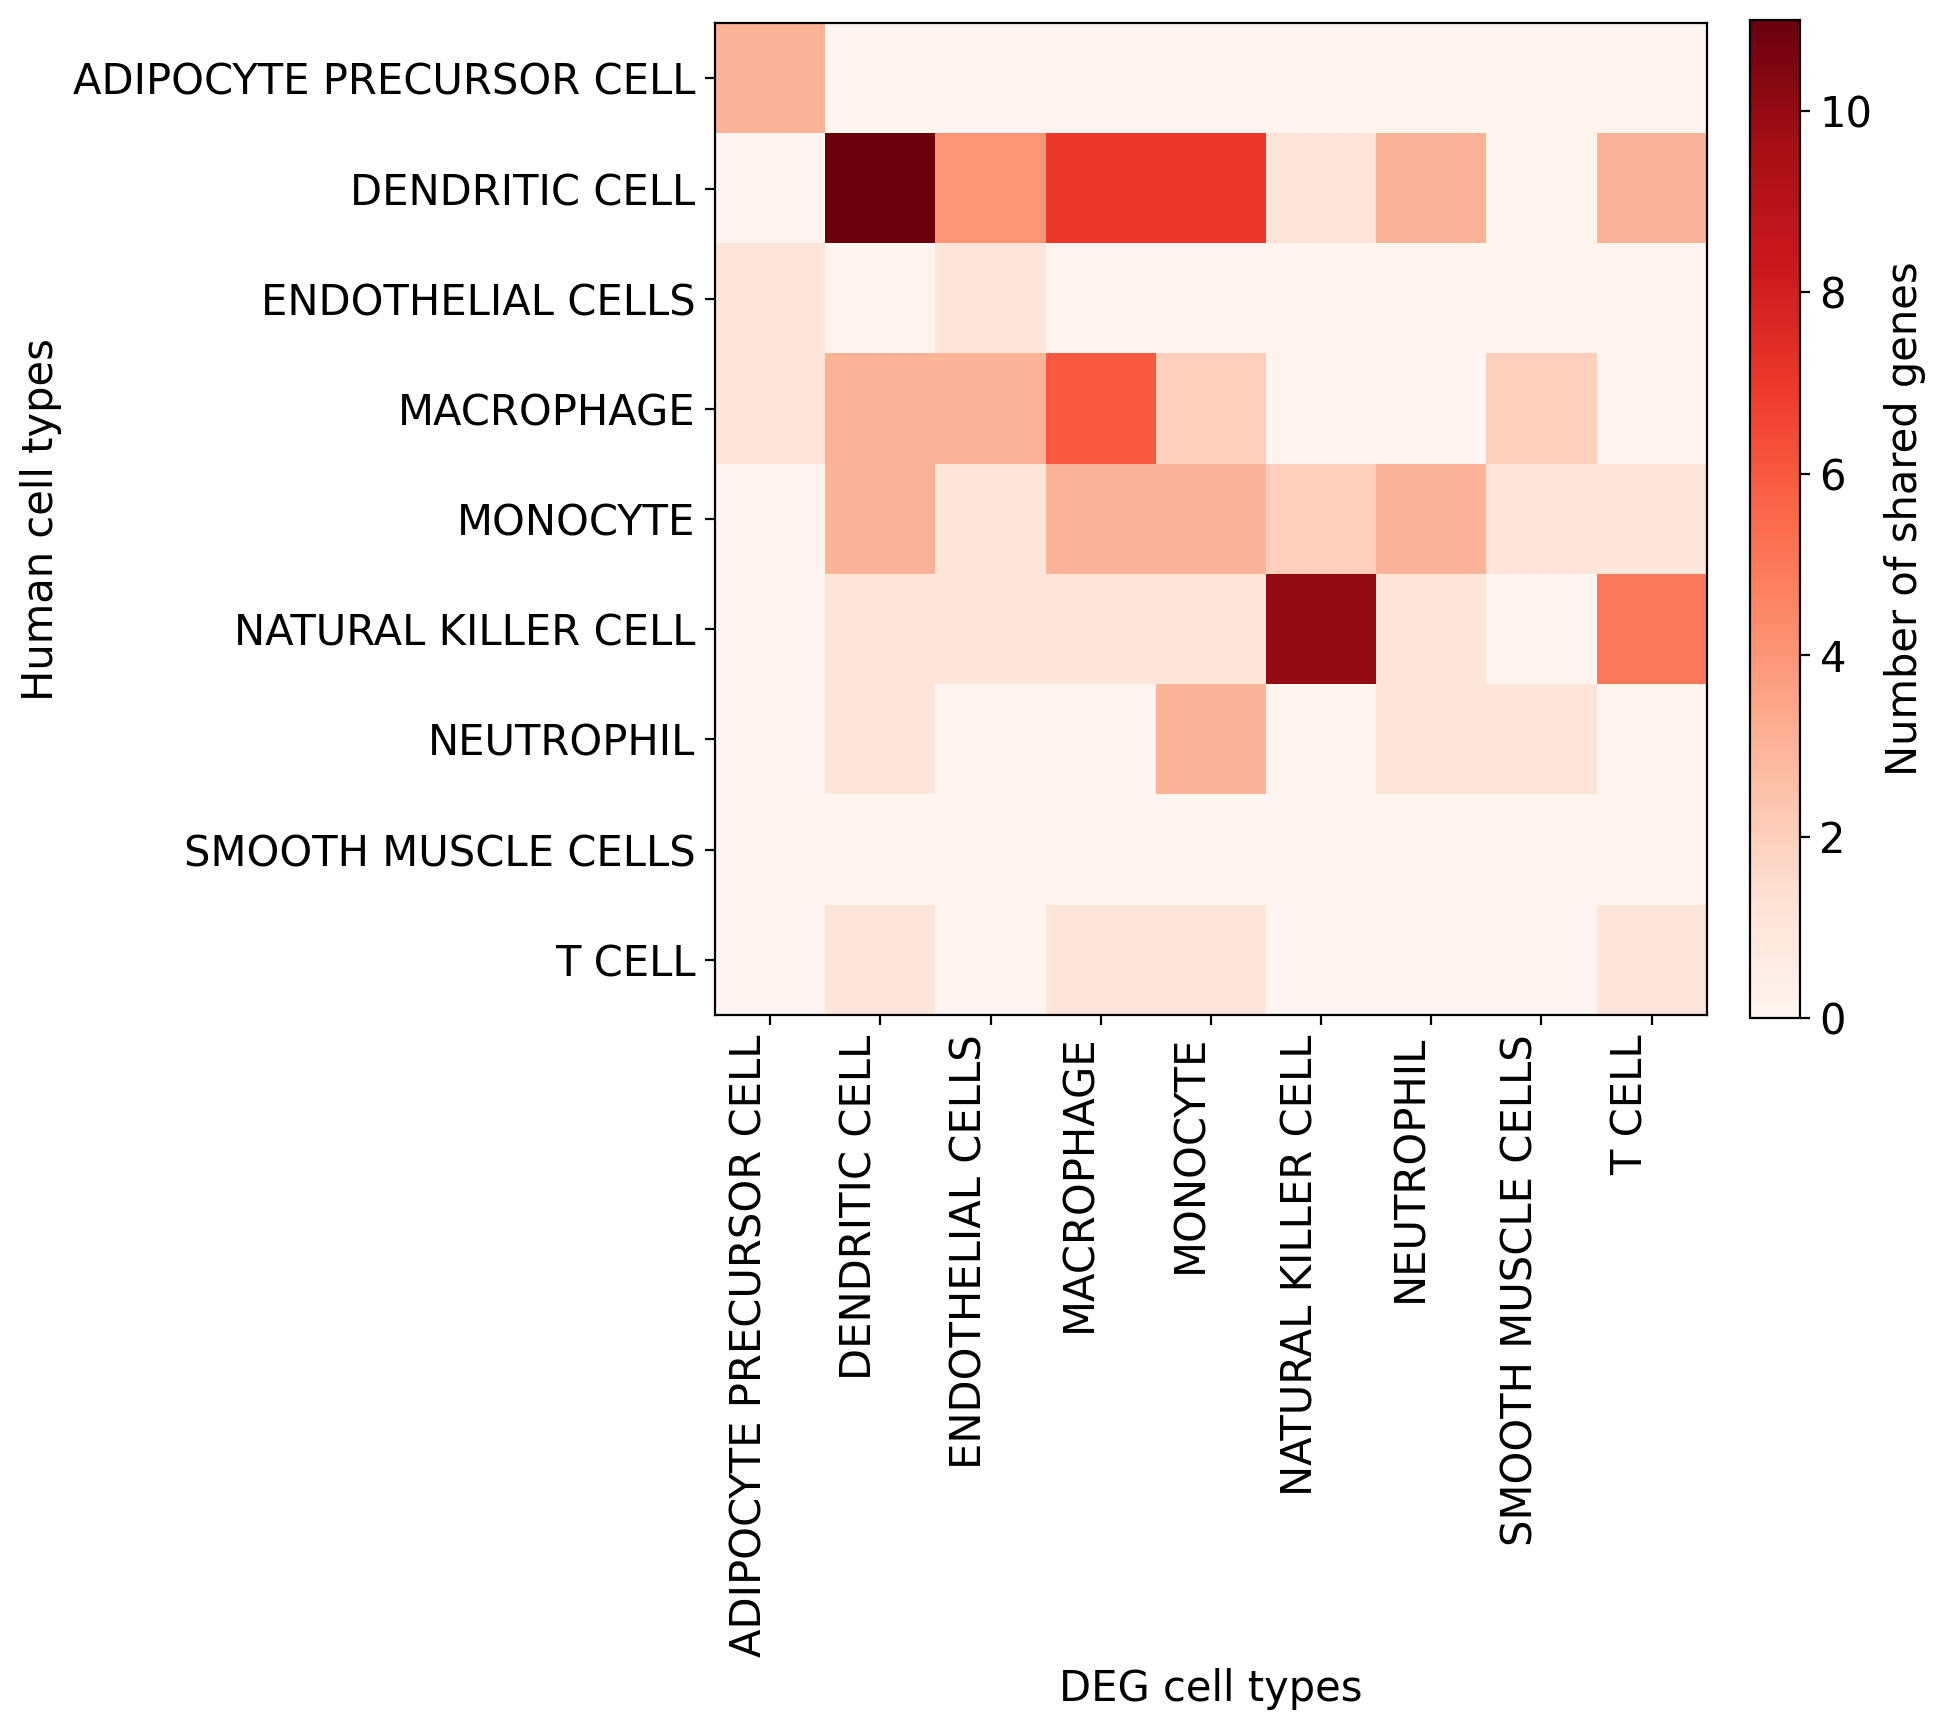

In [677]:
fig, ax = plt.subplots(figsize=(7, 7))
cax = ax.imshow(mtx[:,:,1], cmap="Reds")
ax.set(**{
    "xlabel": "DEG cell types",
    "ylabel": "Human cell types",
    "xticks": np.arange(len(degct)),
    "yticks": np.arange(len(hmnct)),
    "xticklabels": degct,
    "yticklabels": hmnct
})
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')
plt.colorbar(cax,fraction=0.046, pad=0.04, label="Number of shared genes")
plt.show()


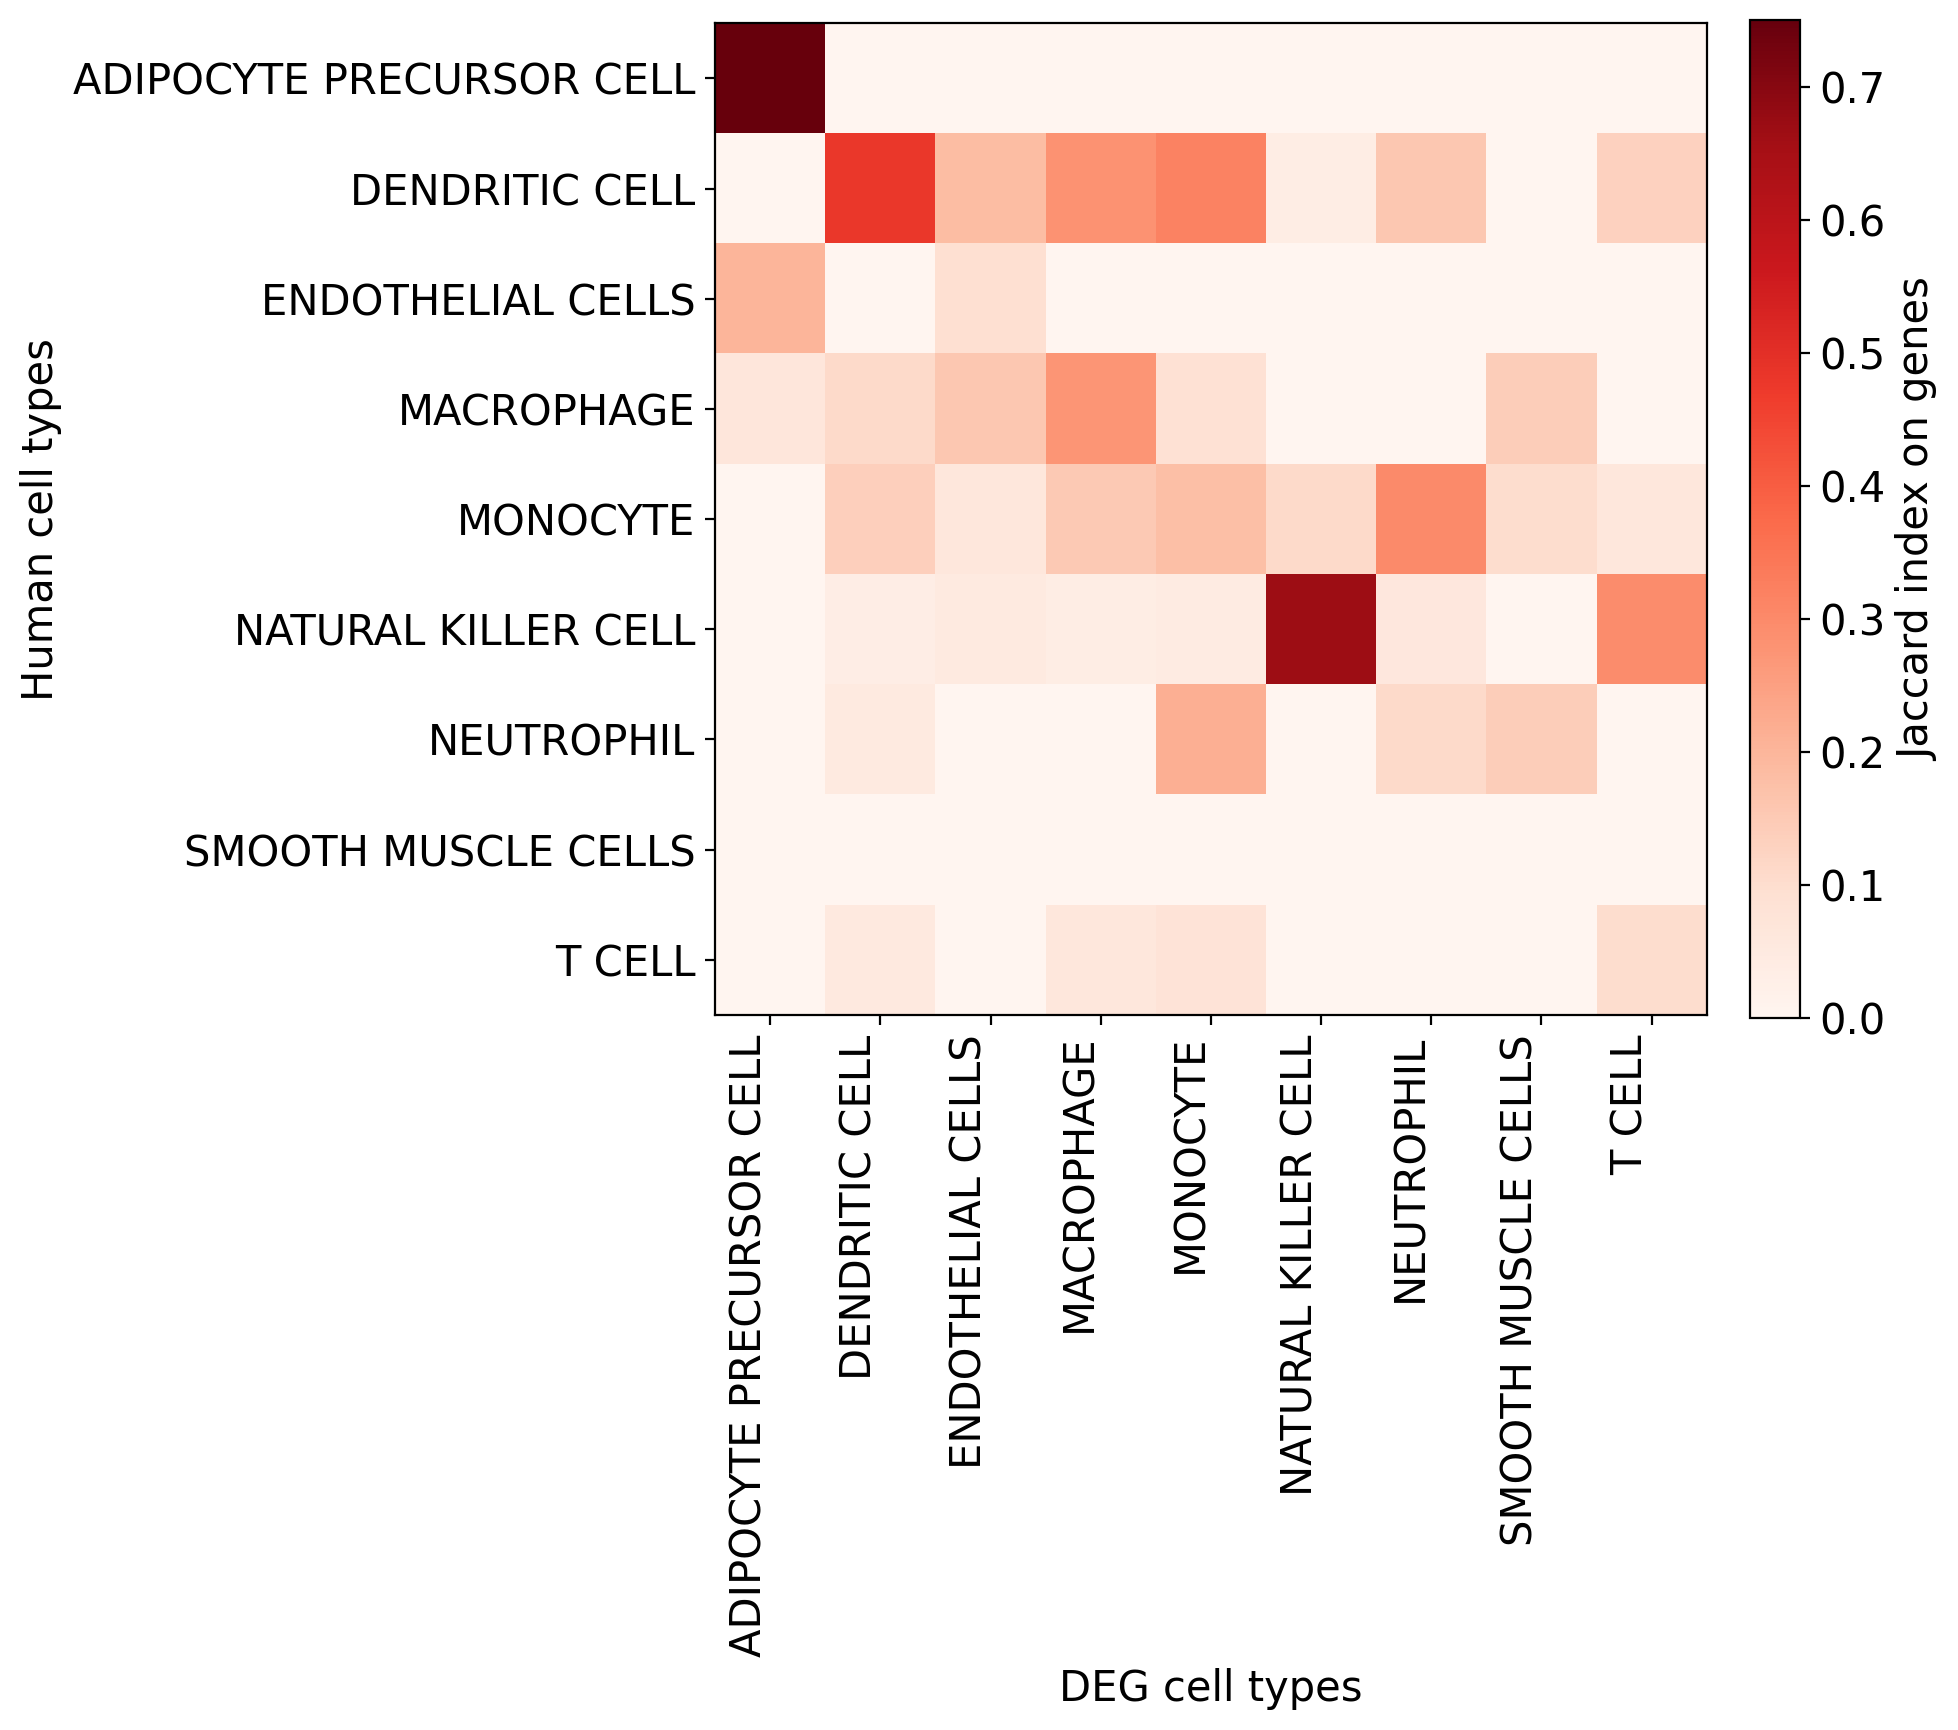

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))
x = mtx[:,:,1] / (mtx.sum(axis=2))
cax = ax.imshow(x, cmap="Reds")
ax.set(**{
    "xlabel": "DEG cell types",
    "ylabel": "Human cell types",
    "xticks": np.arange(len(degct)),
    "yticks": np.arange(len(hmnct)),
    "xticklabels": degct,
    "yticklabels": hmnct
})
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')
plt.colorbar(cax,fraction=0.046, pad=0.04, label="Jaccard index on genes") # chang the min/max to be 0,1

plt.show()


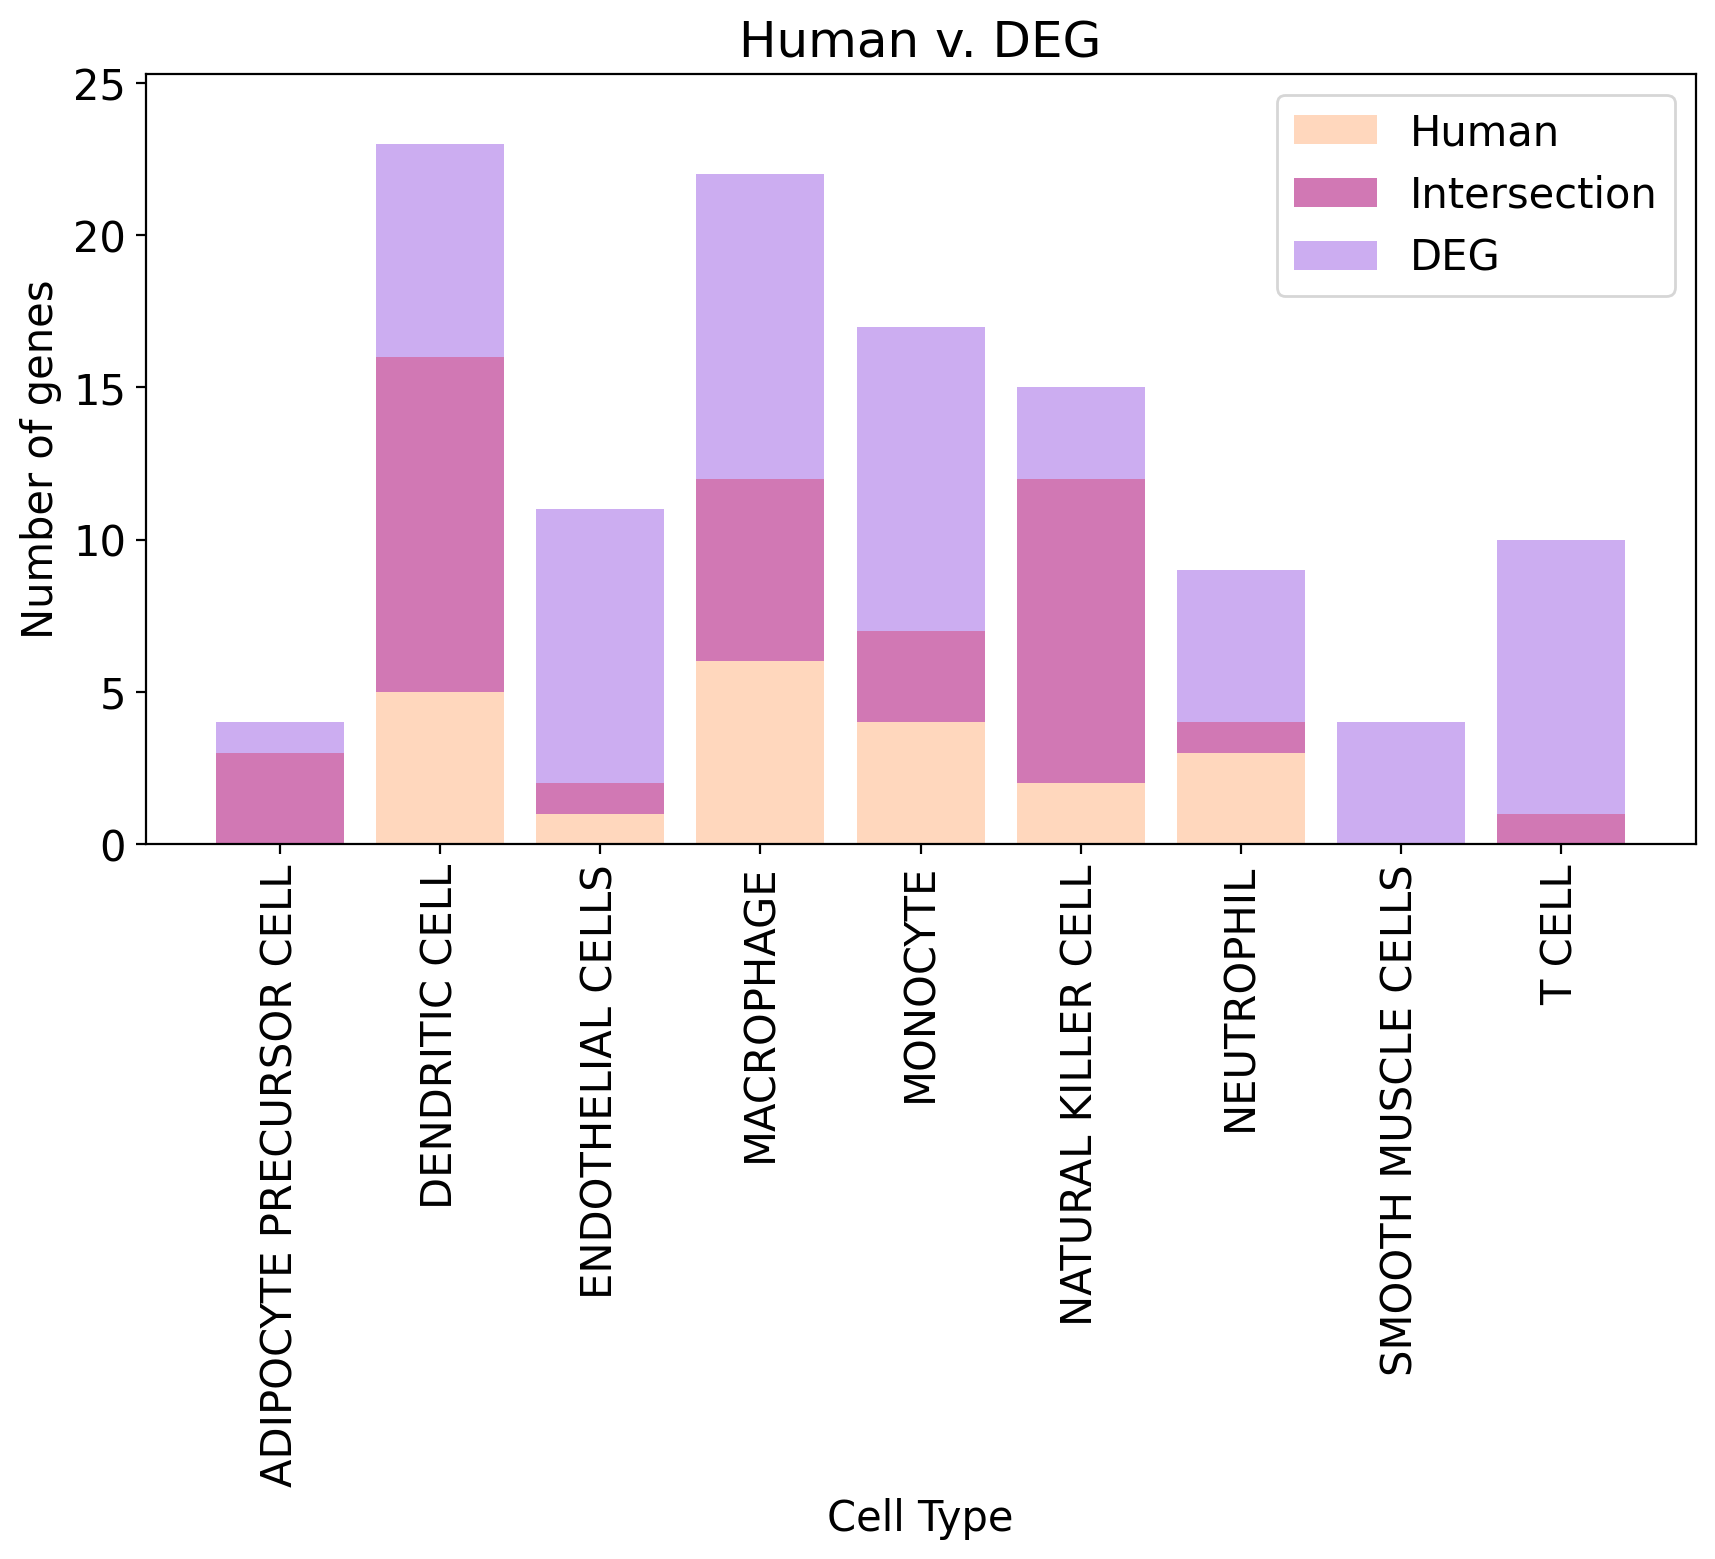

In [681]:
fig, ax = plt.subplots(figsize=(10,5))

y1 = np.diag(mtx[:,:,0]) # left
y2 = np.diag(mtx[:,:,1]) # itx
y3 = np.diag(mtx[:,:,2]) # right

# left, itx, right colors
lc = "#FFB07C"
ic = "#D178B4"
rc = "#9B5DE5"

x = hmnct

ax.bar(x, y1, bottom=0,     color=lc, alpha = 0.5, label=f'Human')
ax.bar(x, y2, bottom=y1,    color=ic, alpha = 1.0, label='Intersection')
ax.bar(x, y3, bottom=y1+y2, color=rc, alpha = 0.5, label=f'DEG')

ax.set(
    **{
        "xlabel" : "Cell Type",
        "ylabel": "Number of genes",
        "title": "Human v. DEG",
        "xticks": np.arange(len(x)),
        "ylim": (0, 1.1 * (y1+y2+y3).max())
    }
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

ax.legend(bbox_to_anchor=(1,1))

# Show the plot
plt.show()


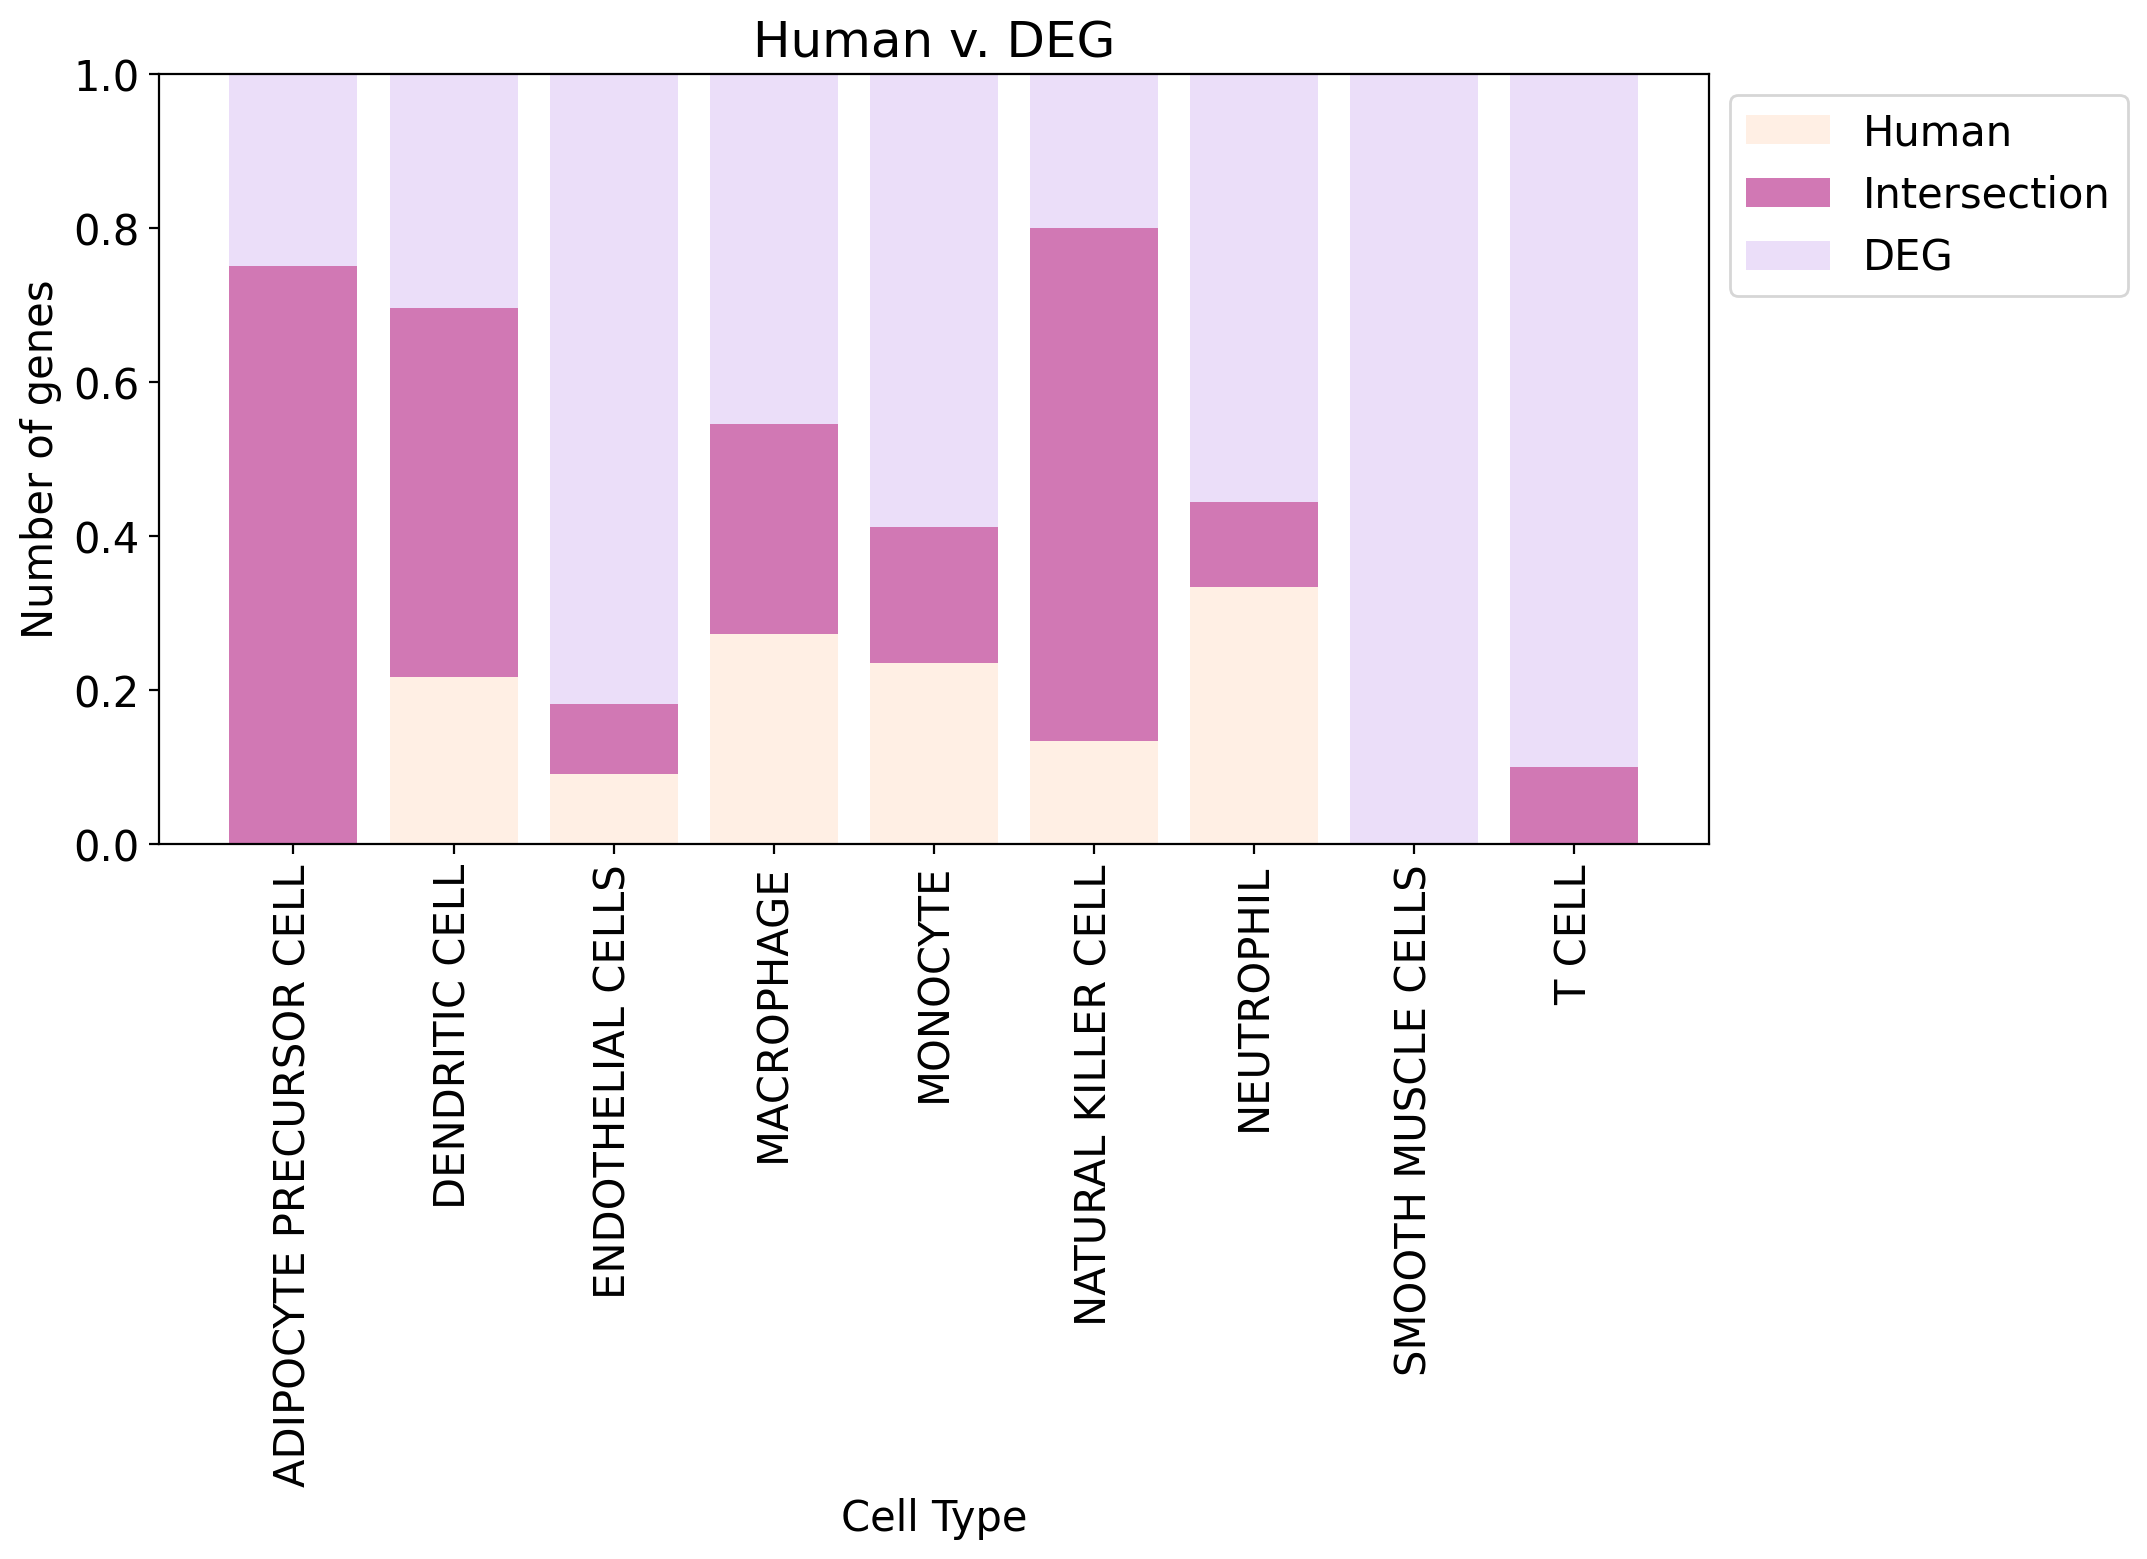

In [682]:
fig, ax = plt.subplots(figsize=(10,5))

y1 = np.diag(norm_mtx[:,:,0]) # left
y2 = np.diag(norm_mtx[:,:,1]) # itx
y3 = np.diag(norm_mtx[:,:,2]) # right

# left, itx, right colors
lc = "#FFB07C"
ic = "#D178B4"
rc = "#9B5DE5"

x = hmnct

ax.bar(x, y1, bottom=0,     color=lc, alpha = 0.2, label=f'Human')
ax.bar(x, y2, bottom=y1,    color=ic, alpha = 1.0, label='Intersection')
ax.bar(x, y3, bottom=y1+y2, color=rc, alpha = 0.2, label=f'DEG')

ax.set(
    **{
        "xlabel" : "Cell Type",
        "ylabel": "Number of genes",
        "title": "Human v. DEG",
        "xticks": np.arange(len(x)),
        "ylim": (0, 1)
    }
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

ax.legend(bbox_to_anchor=(1,1))

# Show the plot
plt.show()


## Ternary Plots

In [683]:
tmp = norm_mtx[np.eye(norm_mtx.shape[0], dtype=bool)]
l = tmp[:,0]
x = tmp[:,1]
r = tmp[:,2]

In [684]:
np.set_printoptions(suppress=True, precision=6)


In [685]:
tmp

array([[0.      , 0.75    , 0.25    ],
       [0.217391, 0.478261, 0.304348],
       [0.090909, 0.090909, 0.818182],
       [0.272727, 0.272727, 0.454545],
       [0.235294, 0.176471, 0.588235],
       [0.133333, 0.666667, 0.2     ],
       [0.333333, 0.111111, 0.555556],
       [0.      , 0.      , 1.      ],
       [0.      , 0.1     , 0.9     ]])

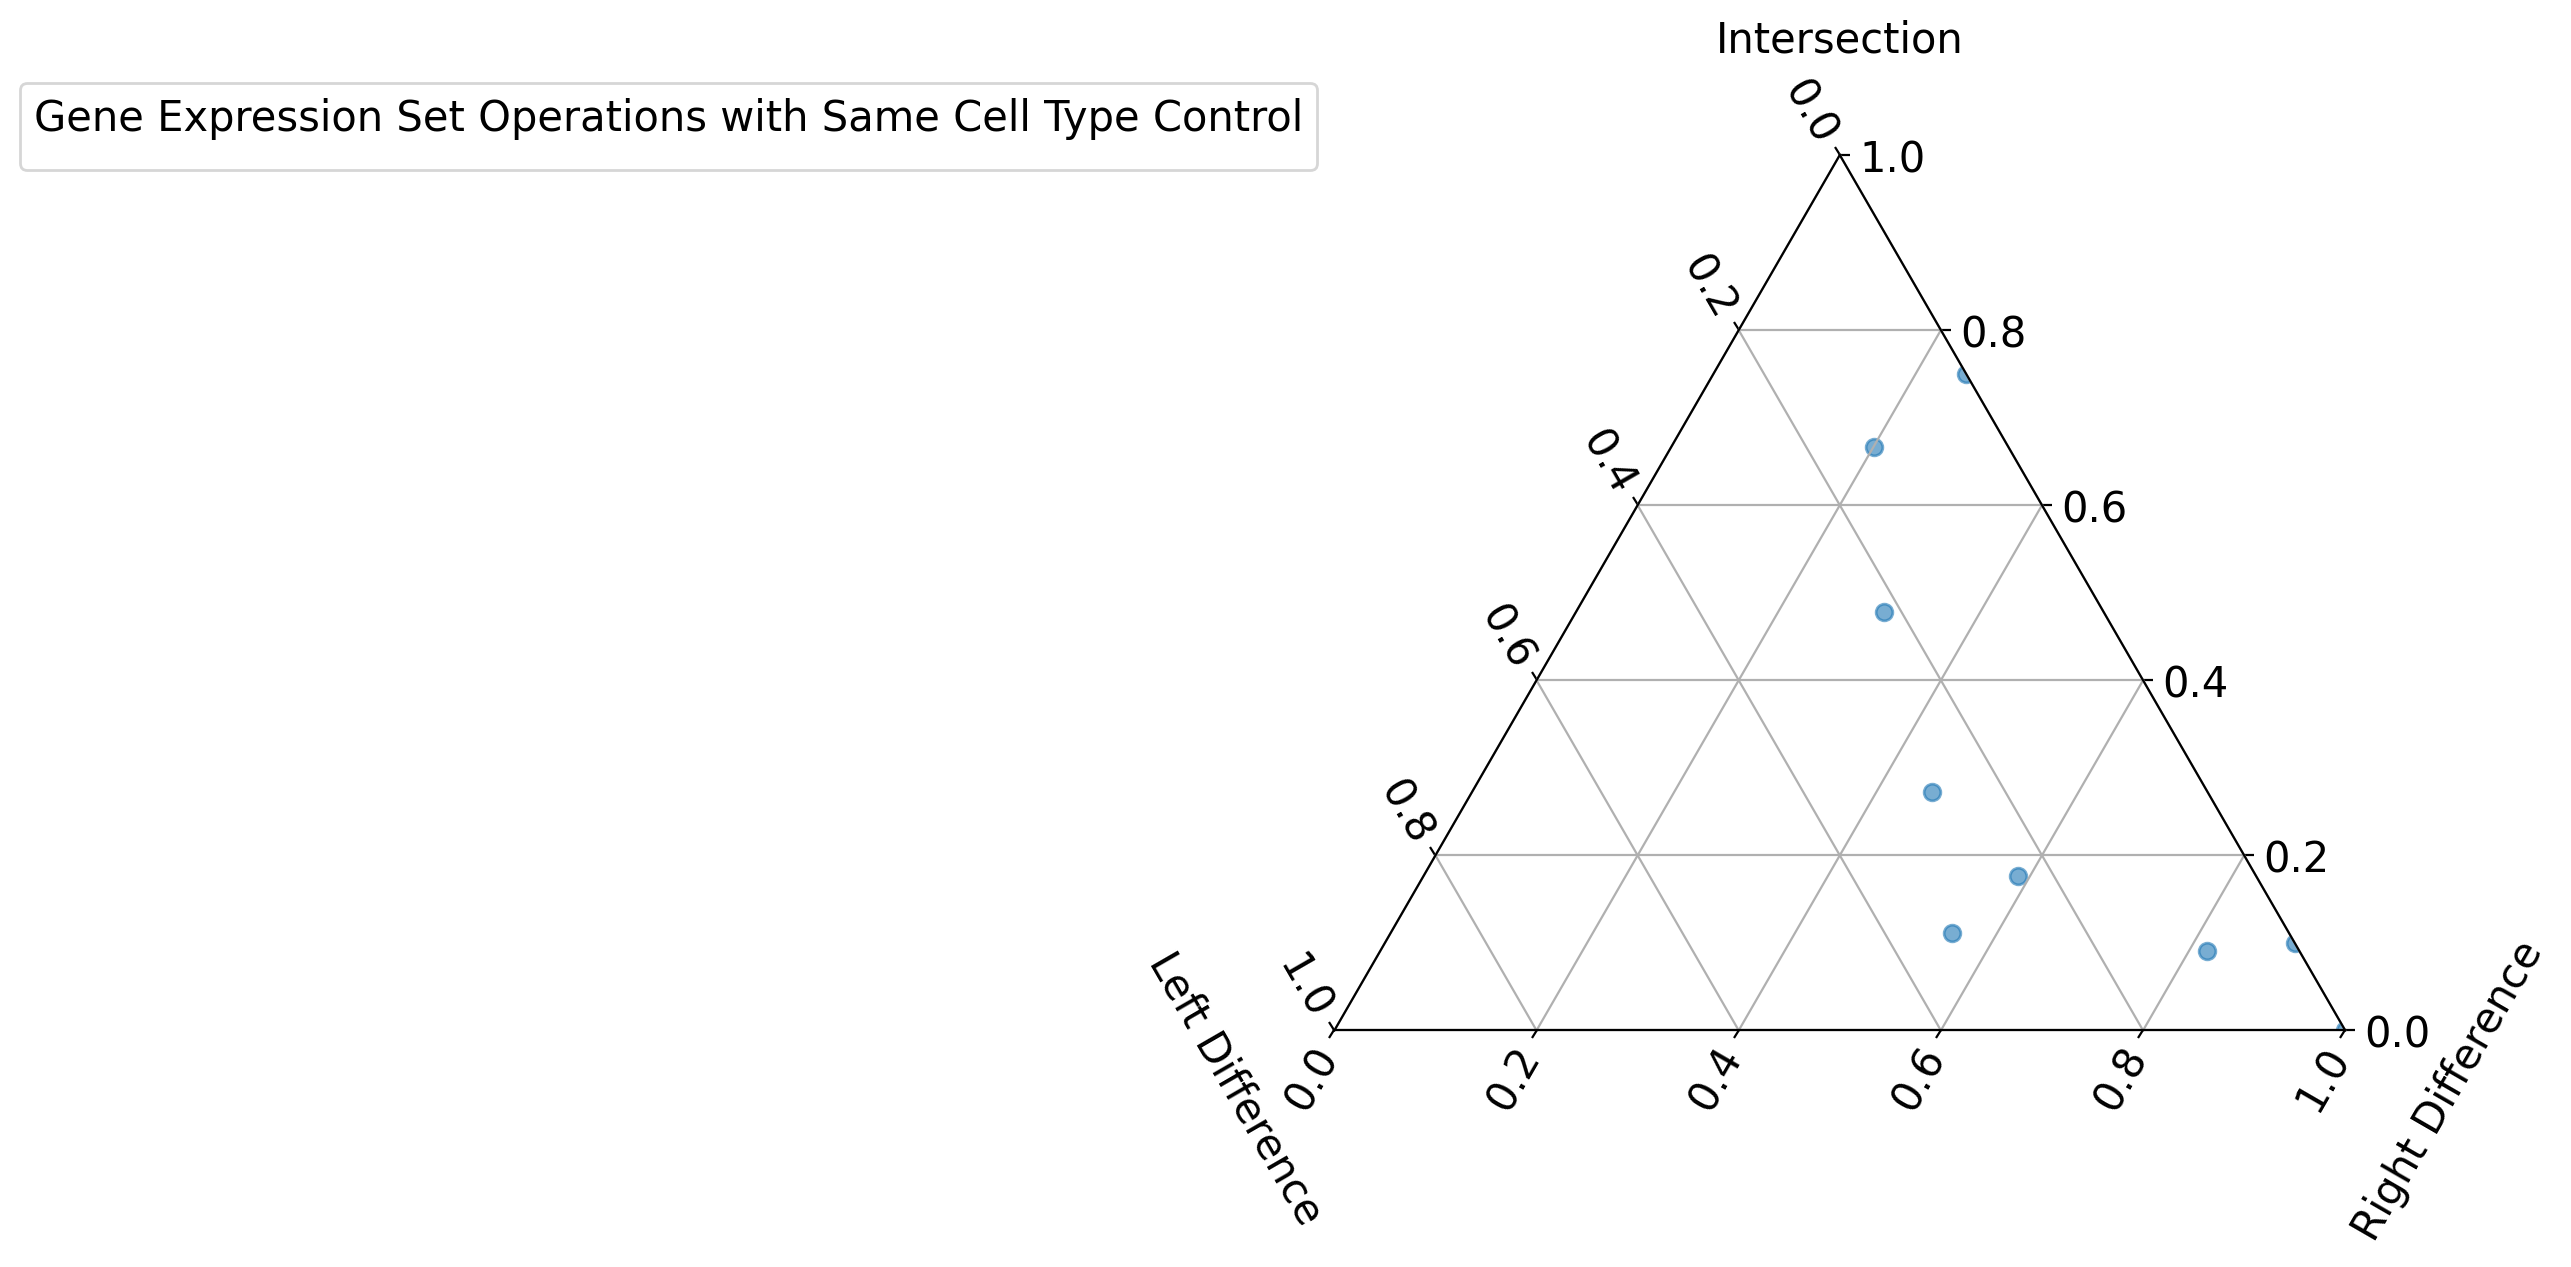

In [686]:
fig = plt.figure(figsize=(15, 15))
fig.subplots_adjust(left=0.075, right=0.85, wspace=0.3)

ax = fig.add_subplot(1, 2, 1, projection="ternary")
pc = ax.scatter(x, l, r, alpha = 0.6, label = f"") # top, left, right

ax.grid(visible=  True, axis = 'both')

ax.set_tlabel('Intersection')
ax.set_llabel('Left Difference')
ax.set_rlabel('Right Difference')

ax.legend(title = "Gene Expression Set Operations with Same Cell Type Control", fontsize = 'small', bbox_to_anchor=(0, 1, 0, .102))

plt.show()